# titanic dataset
$12$
`Titanic was a large ship`


### Environment Setup and Dependency Initialization

This initial cell imports the core data science and data visualization libraries required for the upcoming analysis. Loading these baseline dependencies ensures that all data structures, mathematical operations, and plotting frameworks are globally available throughout the notebook execution environment.

* **`pandas (pd)`**: Used for structured data manipulation, cleaning, and analysis using DataFrames.
* **`numpy (np)`**: Provides high-performance multi-dimensional array objects and fundamental mathematical tools.
* **`matplotlib.pyplot (plt)`**: Serves as the foundational framework for generating static, interactive, and publication-quality visualizations.


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


### Data Acquisition and Initial Inspection

This step loads the dataset into the runtime environment and performs a preliminary structural verification. Reviewing the initial records ensures the schema has been parsed correctly before beginning data transformation.

* **`pd.read_csv()`**: Extracts the raw data from the external source file into a structured DataFrame.
* **`df_titanic.head(5)`**: Displays the first 5 records to inspect columns, formatting, and data alignment.


In [29]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Name      12 non-null     object
 1   Embarked  6 non-null      object
dtypes: object(2)
memory usage: 3.9+ KB


### Dataset Structural Assessment

This step extracts the structural metadata of the DataFrame to evaluate its overall integrity. This diagnostics pass identifies data types, memory footprint, and potential gaps in the dataset.

* **`df_titanic.info()`**: Generates a summary of column names, data types (dtypes), non-null counts, and memory usage.
* **Missing Value Detection**: Identifies which fields contain null values by comparing non-null counts against total rows.
* **Type Validation**: Verifies if numeric, categorical, or text strings are correctly assigned to their respective memory types.


In [30]:
df_titanic=pd.read_csv('titanic.csv')
df_titanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Feature Selection and Dataset Splitting

This step isolates the predictive features from the target variable and removes uninformative attributes. This preparation creates the independent variable matrix needed for subsequent modeling steps.

* **`df_titanic.drop()`**: Excludes specified columns from the dataset along the vertical axis.
* **`axis=1`**: Specifies that whole columns (not rows) are being removed from the operation.
* **`Survived` Removal**: Separates the target label (what we want to predict) from the training features (`x`).
* **`Cabin` Removal**: Drops a column containing excessive missing values that could skew model performance.


In [35]:
df_age = pd.read_csv('titanic ages.csv')
df_age.head()




,Name,Embarked
0,"Icard, Miss. Amelie",S
1,"Stone, Mrs. George Nelson (Martha Evelyn)",S
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


In [38]:
# Remove duplicate names first, keeping the first occurrence
df_age_clean = df_age.drop_duplicates(subset=['Name'])

# Create the lookup map from unique names
embarked_lookup = df_age_clean.set_index('Name')['Embarked']

# Fill the missing values safely
df_titanic['Embarked'] = df_titanic['Embarked'].fillna(df_titanic['Name'].map(embarked_lookup))



In [ ]:
df_titanic[df_titanic['Age'].isnull()]

In [ ]:
# Set embarked to 'S' for the passenger whose name contains 'yyyy'
mask = df_titanic['Name'].str.contains('yyyy', na=False)
df_titanic.loc[mask, 'Embarked'] = 'S'


In [ ]:
df_age.info()

In [ ]:
x = df_titanic.drop(['Cabin', 'Survived'], axis=1)


###  Target Variable Isolation

This step isolates the target label into a dedicated vector. This dependent variable represents the specific outcome the machine learning model will be trained to predict.

* **`df_titanic['Survived']`**: Extracts the ground-truth prediction column from the primary DataFrame.
* **Vector `y`**: Stores the target series independently from the feature matrix `x`.
* **Binary Outcome**: Represents the classification label where `1` indicates survival and `0` indicates non-survival.


In [ ]:
y = df_titanic['Survived']


### Missing Value Imputation

This step addresses missing data within the feature matrix to ensure model stability. Replacing null values prevents computation errors during training while preserving the overall statistical distribution of the attributes.

* **Continuous Variables (`Age`, `Fare`)**: Uses the **`median()`** to fill gaps, as it is robust against outliers.
* **Categorical Variable (`Embarked`)**: Uses the **`mode()[0]`** to replace missing data with the most frequent port of embarkation.
* **`fillna()`**: Permanently applies the calculated replacement values across the designated columns.


###  Target Class Balance Inspection

This step visualizes the distribution of the target variable to check for potential class imbalances. Understanding the ratio between survivors and non-survivors helps determine whether specialized resampling techniques or specific evaluation metrics are necessary for model training.

* **Class Frequency**: Computes the baseline counts for each outcome using the `value_counts()` operation.
* **Survival Disparity**: Compares the absolute volume of non-survivors (`0`) against survivors (`1`).


In [ ]:
x_plot=y.value_counts()
plt.bar(x_plot.index,x_plot)
plt.gca().set_xticks([0,1])
plt.title('distribution of target variable')
plt.show()


### Missing Value Imputation

This step addresses missing data within the feature matrix to ensure model stability. Replacing null values prevents computation errors during training while preserving the overall statistical distribution of the attributes.

* **Continuous Variables (`Age`, `Fare`)**: Uses the **`median()`** to fill gaps, as it is robust against outliers.
* **Categorical Variable (`Embarked`)**: Uses the **`mode()`** to replace missing data with the most frequent port of embarkation.
* **`fillna()`**: Permanently applies the calculated replacement values across the designated columns.


In [ ]:
x['Age'] = x['Age'].fillna(x['Age'].median())
x['Fare'] = x['Fare'].fillna(x['Fare'].median())
x['Embarked'] = x['Embarked'].fillna(x['Embarked'].mode()[0])


###  Categorical Encoding Initialization

This step imports the utility required to convert qualitative text data into quantitative numerical values. Machine learning algorithms require numerical inputs, making this transformation necessary for categorical columns.

* **`LabelEncoder`**: A preprocessing tool that assigns a unique integer to each distinct text category.
* **Ordinal Mapping**: Converts labels into a sequence ranging from `0` to `(number of classes - 1)`.
* **Feature Readiness**: Prepares columns like `Sex` or `Embarked` for algorithmic computation.


In [ ]:
from sklearn.preprocessing import LabelEncoder


### Automated Feature Encoding Loop

This step programmatically scans the feature matrix and converts all non-numeric categorical data into numeric labels. It builds a consolidated training dataset where all attributes are formatted for mathematical modeling.

* **`pd.DataFrame()`**: Initializes an empty DataFrame (`train`) to store the processed, model-ready features.
* **`dtype == 'object'`**: Dynamically detects text or categorical columns requiring conversion.
* **`fit_transform()`**: Learns the unique categories within each column and replaces them with corresponding integers.
* **Data Preservation**: Leaves numeric columns (`int64`, `float64`) unchanged and copies them directly into the new DataFrame.


In [ ]:
train = pd.DataFrame()
label = LabelEncoder()

for c in x.columns:
    if x[c].dtype == 'object':
        train[c] = label.fit_transform(x[c])
    else:
        train[c] = x[c]


###  Encoded Feature Verification

This step retrieves the top records of the newly constructed feature matrix. Reviewing this output verifies that all categorical features were converted into numerical formats and that numerical features remained intact.

* **`train.head(5)`**: Outputs the first 5 records of the processed dataset for visual alignment verification.
* **Integrity Pass**: Checks that no column names were dropped, missing values were correctly imputed, and row indices line up.
* **Model Readiness**: Ensures the entire matrix contains purely numeric values, fulfilling the operational requirements of scikit-learn estimators.


In [ ]:
train.head(5)

###  Cross-Validation and Modeling Dependencies

This step imports the advanced validation and modeling tools required to build robust evaluation workflows. It supplements the baseline classifier with structural validation frameworks to mitigate overfitting risks.

* **`KFold`**: Cross-validation splitter that divides the dataset into $K$ sequential folds for iterative training and validation.
* **`base`**: Provides core scikit-learn mixins and object clones useful for building custom estimators or pipeline elements.
* **`train_test_split` / `LogisticRegression` / `accuracy_score`**: Core utilities required for standard data partition, model fitting, and baseline accuracy assessment.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn import base


In [ ]:
###  Classification Pipeline Function Definition

This step defines a reusable function to automate data splitting, model training, and performance evaluation. It isolates the model logic to ensure consistent testing constraints across different feature variations.

* **`train_test_split()`**: Allocates **20%** of the data for testing (`test_size=0.2`) and locks the shuffle pattern (`random_state=42`) for reproducibility.
* **`LogisticRegression()`**: Instantiates the classifier with a raised iteration ceiling (`max_iter=1000`) to guarantee numerical convergence.
* **`lr.fit()`**: Trains the model by optimization weights against the training subsets (`x_train`, `y_train`).
* **`accuracy_score()`**: Evaluates performance by computing the ratio of correctly predicted outcomes over total test records.


In [ ]:
def logistic(x, y):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
    lr = LogisticRegression(max_iter=1000)
    lr.fit(x_train, y_train)
    y_pre = lr.predict(x_test)
    print('Accuracy:', accuracy_score(y_test, y_pre))



### Logistic Regression Model Execution

This step passes the processed feature matrix and target vector into a helper function to train and evaluate a Logistic Regression model. This assesses the baseline predictive performance of our classification strategy.

* **`logistic()`**: A custom user-defined function designed to automate model training, prediction, and metric logging.
* **`train` Argument**: Supplies the fully encoded, numeric feature matrix containing independent variables.
* **`y` Argument**: Supplies the isolated binary target vector containing the survival outcomes.


In [ ]:
logistic(train,y)

In [ ]:
df_titanic = pd.read_csv('titanic ages.csv')

In [ ]:
df_titanic.head()

##  One-Hot Encoding


In [47]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

train2 = pd.DataFrame()

for c in df_titanic.columns:
  
    if c in ['Name', 'Ticket', 'PassengerId']:
        continue
        
    if df_titanic[c].dtype == 'object':
        ohe = OneHotEncoder(drop='first', sparse_output=False)
        encoded_array = ohe.fit_transform(df_titanic[[c]])
        feature_names = ohe.get_feature_names_out([c])
        
        encoded_df = pd.DataFrame(encoded_array, columns=feature_names, index=df_titanic.index)
        train2 = pd.concat([train2, encoded_df], axis=1)
    else:
        train2[c] = df_titanic[c]


In [48]:
train2.head()


,Embarked_Q,Embarked_S,Embarked_nan
0,0.0,1.0,0.0
1,0.0,1.0,0.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0


DATASET LOADED
Dataset shape: (1309, 12)


Label Encoding
Number of features: 7
Accuracy: 0.8435

              precision    recall  f1-score   support

           0       0.85      0.91      0.88       163
           1       0.83      0.74      0.78        99

    accuracy                           0.84       262
   macro avg       0.84      0.82      0.83       262
weighted avg       0.84      0.84      0.84       262


One-Hot Encoding
Number of features: 8
Accuracy: 0.8435

              precision    recall  f1-score   support

           0       0.85      0.91      0.88       163
           1       0.83      0.74      0.78        99

    accuracy                           0.84       262
   macro avg       0.84      0.82      0.83       262
weighted avg       0.84      0.84      0.84       262


Feature Hashing
Number of features: 13
Accuracy: 0.8435

              precision    recall  f1-score   support

           0       0.85      0.91      0.88       163
           1       0.83

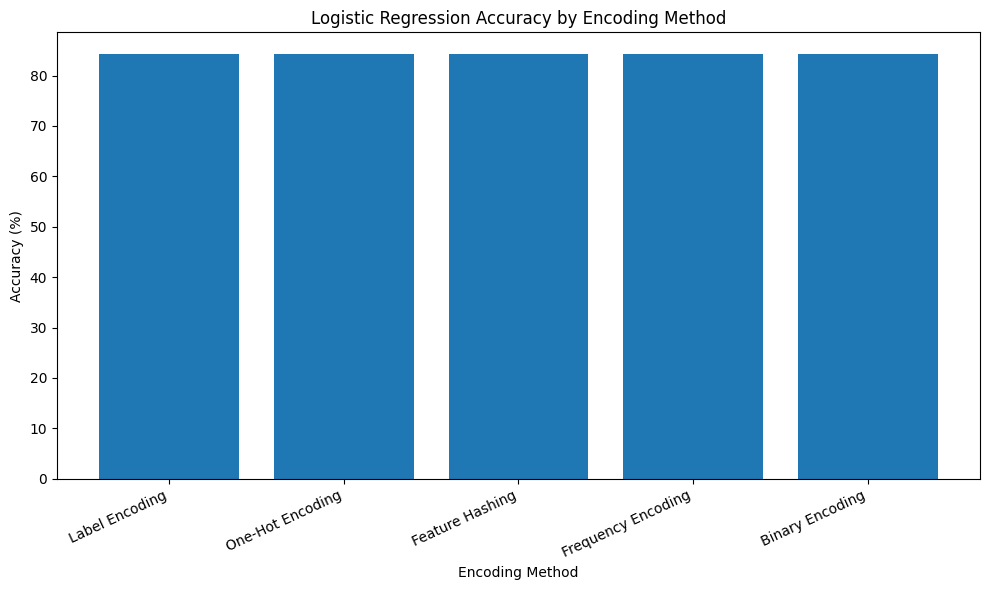

In [1]:
# ============================================================
# CATEGORICAL ENCODING COMPARISON EXPERIMENT
# Titanic Dataset
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction import FeatureHasher


# ============================================================
# 1. LOAD THE ORIGINAL TITANIC DATASET
# ============================================================

df = pd.read_csv('titanic.csv')

print("=" * 60)
print("DATASET LOADED")
print("=" * 60)
print("Dataset shape:", df.shape)
print()


# ============================================================
# 2. SELECT FEATURES AND TARGET
# ============================================================

# Remove columns that are not being used as predictive features
X = df.drop(['Survived', 'Cabin', 'Name', 'Ticket', 'PassengerId'], axis=1)

# Target variable
y = df['Survived']


# ============================================================
# 3. HANDLE MISSING VALUES
# ============================================================

# Numerical columns
X['Age'] = X['Age'].fillna(X['Age'].median())
X['Fare'] = X['Fare'].fillna(X['Fare'].median())

# Categorical column
X['Embarked'] = X['Embarked'].fillna(X['Embarked'].mode()[0])


# ============================================================
# 4. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ============================================================
# 5. IDENTIFY CATEGORICAL AND NUMERICAL FEATURES
# ============================================================

categorical_columns = ['Sex', 'Embarked']

numerical_columns = [
    'Pclass',
    'Age',
    'SibSp',
    'Parch',
    'Fare'
]


# ============================================================
# STORAGE FOR RESULTS
# ============================================================

results = []


# ============================================================
# 6. HELPER FUNCTION FOR MODEL TRAINING
# ============================================================

def evaluate_model(X_train_encoded, X_test_encoded, method_name):

    model = LogisticRegression(max_iter=1000)

    model.fit(X_train_encoded, y_train)

    predictions = model.predict(X_test_encoded)

    accuracy = accuracy_score(y_test, predictions)

    results.append({
        'Encoding Method': method_name,
        'Number of Features': X_train_encoded.shape[1],
        'Accuracy': accuracy
    })

    print("\n" + "=" * 60)
    print(method_name)
    print("=" * 60)
    print("Number of features:", X_train_encoded.shape[1])
    print("Accuracy:", round(accuracy, 4))
    print()
    print(classification_report(y_test, predictions))


# ============================================================
# 7. LABEL ENCODING
# ============================================================

X_train_label = X_train[numerical_columns].copy()
X_test_label = X_test[numerical_columns].copy()

for column in categorical_columns:

    # Create mapping using training data only
    categories = X_train[column].astype(str).unique()

    label_mapping = {
        category: index
        for index, category in enumerate(categories)
    }

    X_train_label[column] = (
        X_train[column]
        .astype(str)
        .map(label_mapping)
    )

    # Unknown categories in test data become -1
    X_test_label[column] = (
        X_test[column]
        .astype(str)
        .map(label_mapping)
        .fillna(-1)
    )

evaluate_model(
    X_train_label,
    X_test_label,
    'Label Encoding'
)


# ============================================================
# 8. ONE-HOT ENCODING
# ============================================================

ohe = OneHotEncoder(
    drop='first',
    sparse_output=False,
    handle_unknown='ignore'
)

X_train_cat_ohe = ohe.fit_transform(
    X_train[categorical_columns]
)

X_test_cat_ohe = ohe.transform(
    X_test[categorical_columns]
)

X_train_ohe = np.hstack([
    X_train[numerical_columns].values,
    X_train_cat_ohe
])

X_test_ohe = np.hstack([
    X_test[numerical_columns].values,
    X_test_cat_ohe
])

evaluate_model(
    X_train_ohe,
    X_test_ohe,
    'One-Hot Encoding'
)


# ============================================================
# 9. FEATURE HASHING
# ============================================================

# Convert categorical values into dictionaries
train_hash_data = [
    {
        column: str(row[column])
        for column in categorical_columns
    }
    for _, row in X_train.iterrows()
]

test_hash_data = [
    {
        column: str(row[column])
        for column in categorical_columns
    }
    for _, row in X_test.iterrows()
]

# Fixed number of hashing dimensions
hasher = FeatureHasher(
    n_features=8,
    input_type='dict'
)

X_train_hash_cat = hasher.transform(
    train_hash_data
).toarray()

X_test_hash_cat = hasher.transform(
    test_hash_data
).toarray()

X_train_hash = np.hstack([
    X_train[numerical_columns].values,
    X_train_hash_cat
])

X_test_hash = np.hstack([
    X_test[numerical_columns].values,
    X_test_hash_cat
])

evaluate_model(
    X_train_hash,
    X_test_hash,
    'Feature Hashing'
)


# ============================================================
# 10. FREQUENCY / COUNT ENCODING
# ============================================================

X_train_freq = X_train[numerical_columns].copy()
X_test_freq = X_test[numerical_columns].copy()

for column in categorical_columns:

    # Calculate category frequencies from training data
    frequency_mapping = (
        X_train[column]
        .value_counts(normalize=True)
        .to_dict()
    )

    X_train_freq[column] = (
        X_train[column]
        .map(frequency_mapping)
        .fillna(0)
    )

    X_test_freq[column] = (
        X_test[column]
        .map(frequency_mapping)
        .fillna(0)
    )

evaluate_model(
    X_train_freq,
    X_test_freq,
    'Frequency Encoding'
)


# ============================================================
# 11. BINARY ENCODING
# ============================================================

def binary_encode_column(train_column, test_column, column_name):

    # Get unique categories from training data
    categories = train_column.astype(str).unique()

    # Assign each category an integer
    category_mapping = {
        category: index
        for index, category in enumerate(categories)
    }

    train_numbers = (
        train_column
        .astype(str)
        .map(category_mapping)
        .fillna(0)
        .astype(int)
    )

    test_numbers = (
        test_column
        .astype(str)
        .map(category_mapping)
        .fillna(0)
        .astype(int)
    )

    # Determine number of binary digits required
    max_number = max(len(categories) - 1, 1)
    number_of_bits = max(1, int(np.ceil(np.log2(max_number + 1))))

    train_binary = pd.DataFrame(index=train_column.index)
    test_binary = pd.DataFrame(index=test_column.index)

    for bit in range(number_of_bits):

        train_binary[
            f'{column_name}_binary_{bit}'
        ] = (train_numbers // (2 ** bit)) % 2

        test_binary[
            f'{column_name}_binary_{bit}'
        ] = (test_numbers // (2 ** bit)) % 2

    return train_binary, test_binary


X_train_binary = X_train[numerical_columns].copy()
X_test_binary = X_test[numerical_columns].copy()

for column in categorical_columns:

    train_binary, test_binary = binary_encode_column(
        X_train[column],
        X_test[column],
        column
    )

    X_train_binary = pd.concat(
        [X_train_binary, train_binary],
        axis=1
    )

    X_test_binary = pd.concat(
        [X_test_binary, test_binary],
        axis=1
    )

evaluate_model(
    X_train_binary,
    X_test_binary,
    'Binary Encoding'
)


# ============================================================
# 12. CREATE RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results)

results_df['Accuracy (%)'] = (
    results_df['Accuracy'] * 100
).round(2)

print("\n\n")
print("=" * 60)
print("FINAL ENCODING COMPARISON")
print("=" * 60)

print(
    results_df[
        [
            'Encoding Method',
            'Number of Features',
            'Accuracy (%)'
        ]
    ].to_string(index=False)
)


# ============================================================
# 13. IDENTIFY THE BEST ENCODING METHOD
# ============================================================

best_result = results_df.loc[
    results_df['Accuracy'].idxmax()
]

print("\n")
print("=" * 60)
print("BEST PERFORMING ENCODING")
print("=" * 60)

print(
    "Method:",
    best_result['Encoding Method']
)

print(
    "Accuracy:",
    round(best_result['Accuracy'] * 100, 2),
    "%"
)

print(
    "Number of features:",
    int(best_result['Number of Features'])
)


# ============================================================
# 14. VISUAL COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    results_df['Encoding Method'],
    results_df['Accuracy (%)']
)

plt.xlabel('Encoding Method')
plt.ylabel('Accuracy (%)')
plt.title('Logistic Regression Accuracy by Encoding Method')

plt.xticks(
    rotation=25,
    ha='right'
)

plt.tight_layout()
plt.show()